In [13]:
#cheb differential Matrix inner Neumann Boundary condition
module chebyshev_method

    using LinearAlgebra

    export chebyshev_D
    # Chebyshev compute D = differentiation matrix, x = Chebyshev grid

    function  chebyshev_D(N)

        if N==0
            D = 0;
            x = 1;
            return D, x
        else
            θ = range(0,length=N+1,stop=pi)
            x = reshape(-cos.(θ), N+1, 1)
            c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
            X = repeat(x, 1, N+1);
            dX = X - X';
            D = (c * (1 ./ c)') ./ (dX .+ I(N+1));   # off-diagonal entries
            D = D - diagm(vec(sum(D, dims=2)));      # diagonal entries
            return D, x
        end
    end
end

Main.chebyshev_method

In [14]:
using .chebyshev_method
N=199
D,x=chebyshev_D(N)
DM=zeros(N+1,N+1)
D1=zeros(N+1,N+1)
DM.=D
for i = 2:N+1
    D[i,:]=(-1*D[i,1]/D[1,1])*D[1,:].+D[i,:]
end
for i = 2:N
    D[i,:]=(-1*D[i,N+1]/D[N+1,N+1])*D[N+1,:].+D[i,:]
end
# D1[:,1]=D1[:,N+1].=0
# DM[:,1]=DM[:,N+1].=0
D2=DM*D
@show D

200×200 Matrix{Float64}:
 -13200.5          16050.0       …      -1.00006       0.5
      0.0          -2872.53              0.315272      0.0
      1.13687e-13  -1455.48             -0.225914      0.0
      5.68434e-14    461.15              0.209421      0.0
      0.0           -230.167            -0.203713      0.0
      0.0            139.305     …       0.201141      0.0
      0.0            -93.8406           -0.199819      0.0
      0.0             67.6941            0.1991        0.0
     -7.10543e-15    -51.2217           -0.198714      0.0
      0.0             40.151             0.198532      0.0
      ⋮                          ⋱                 
      0.0              0.198714         51.2217        0.0
      0.0             -0.1991          -67.6941        0.0
      0.0              0.199819         93.8406        1.42109e-14
      0.0             -0.201141       -139.305         0.0
      0.0              0.203713  …     230.167         0.0
      0.0             -0.20942

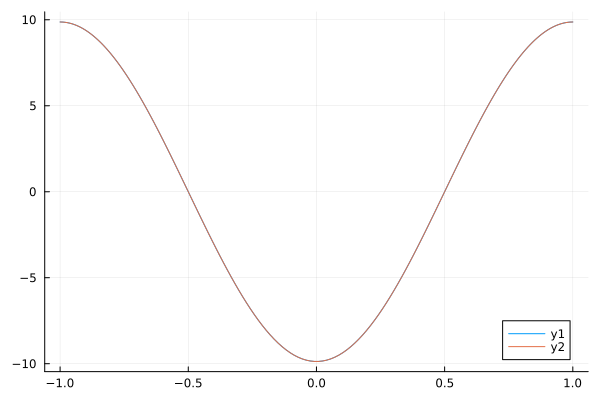

In [15]:
using Plots
using. chebyshev_method
X=x
y=cos.(pi*X)
dy=-pi*sin.(pi*X)
dy_1=D1*y
ddy=-pi^2*cos.(pi*X)
ddy_1=D2*y
d4y=pi^4*cos.(pi*X)
d4y_1=D2^2*y
plot(X,ddy)
plot!(X,ddy_1)
# d4y-d4y_1
# plot(d4y-d4y_1)

In [16]:
D2=D2[2:end-1,2:end-1]
N=N-2


197

In [17]:
using LinearAlgebra
using Arpack
using.chebyshev_method
Re=10000
α=1
U_0=zeros(N+1,1)
U_0[:,1]=ones(N+1,1)-x[2:end-1,1].^2
A=(D2-α^2*I(N+1))^2-(0+α*Re*im)*(D2.*U_0[:,1]-U_0[:,1].*(α^2*I(N+1))+2*I(N+1)) #O-S coefficient matrix
B=(0+Re*α*im)*((α^2)*I(N+1)-D2)
NewA=A[2:N,2:N]
NewB=B[2:N,2:N]
c=eigen(NewA,NewB)
# filter(x->imag(x)>0,values)
d=c.values
filter(x->0<imag(x)<1,d)

1-element Vector{ComplexF64}:
 0.23753615095210037 + 0.003741392382366536im

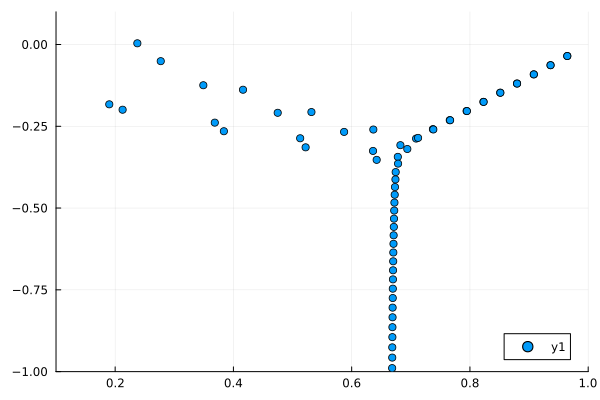

In [18]:
using Plots
scatter(real(d),imag(d),xlims=[0.1,1],ylims=[-1,0.1])